<a href="https://colab.research.google.com/github/abdelkadergelany/Intrusion-Detection-in-IoT-Based-Network/blob/main/Protocol_AnalyZer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Importing  Libraries

In [28]:
# data cleaning and plots
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('ggplot')
%matplotlib inline

# sklearn: data preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder ,MinMaxScaler
from sklearn import preprocessing,svm,metrics

# sklearn: train model
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score, accuracy_score
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, classification_report

# sklearn classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier

#Feature selection
from sklearn.feature_selection import chi2,RFE
from sklearn.feature_selection import SelectKBest
import xgboost, lightgbm
from sklearn.svm import SVR

# Data Processing

## Load Data

**UNSW-NB15: a comprehensive data set for network intrusion detection systems**


attack_cat: This dataset has nine types of attacks, namely, Fuzzers, Analysis, Backdoors, DoS, Exploits, Generic, Reconnaissance, Shellcode and Worms.

Label: 0 for normal and 1 for attack records

In [2]:
# Load data
train = pd.read_csv('https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_training-set.csv')
test = pd.read_csv('https://raw.githubusercontent.com/Nir-J/ML-Projects/master/UNSW-Network_Packet_Classification/UNSW_NB15_testing-set.csv')
combined_data = pd.concat([train, test]).drop(['id'],axis=1)

In [3]:
# Look at the first 5 rows
combined_data.head(n=5)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.295600,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.000000,0.000000,0.000000,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.915000,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.000000,0.000000,0.000000,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,62,252,1572.271851,60929.230470,1,6,231.875571,102.737203,17179.586860,11420.926230,255,2116150707,2963114973,255,0.111897,0.061458,0.050439,46,824,0,0,7,1,2,1,1,3,0,0,0,2,6,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,62,252,2740.178955,3358.622070,1,3,152.876547,90.235726,259.080172,4991.784669,255,1107119177,1047442890,255,0.000000,0.000000,0.000000,52,64,0,0,1,1,2,1,1,3,1,1,0,2,1,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373826,254,252,8561.499023,3987.059814,2,1,47.750333,75.659602,2415.837634,115.807000,255,2436137549,1977154190,255,0.128381,0.071147,0.057234,53,45,0,0,43,1,2,2,1,40,0,0,0,2,39,0,Normal,0


In [4]:
# information of the data: 
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 257673 entries, 0 to 82331
Data columns (total 44 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   dur                257673 non-null  float64
 1   proto              257673 non-null  object 
 2   service            257673 non-null  object 
 3   state              257673 non-null  object 
 4   spkts              257673 non-null  int64  
 5   dpkts              257673 non-null  int64  
 6   sbytes             257673 non-null  int64  
 7   dbytes             257673 non-null  int64  
 8   rate               257673 non-null  float64
 9   sttl               257673 non-null  int64  
 10  dttl               257673 non-null  int64  
 11  sload              257673 non-null  float64
 12  dload              257673 non-null  float64
 13  sloss              257673 non-null  int64  
 14  dloss              257673 non-null  int64  
 15  sinpkt             257673 non-null  float64
 16  din

In [ ]:
# check if there are Null values
combined_data.isnull().sum()

In [6]:
# Discard the rows with missing values

data_to_use = combined_data.dropna()

# Shape of the data: we could see that the number of rows remains the same as no null values were reported
data_to_use.shape

(257673, 44)

<h1>Contamination mean pollution (outliers) in data</h1>

In [7]:
# Contaminsation mean pollution (outliers) in data
tmp = train.where(train['attack_cat'] == "Normal").dropna()
contamination = round(1 - len(tmp)/len(train), 2)
print("train contamination ", contamination)

tmp = test.where(test['attack_cat'] == "Normal").dropna()
print("test  contamination ", round(1 - len(tmp)/len(test),2),'\n')

if contamination > 0.5:
    print(f'contamination is {contamination}, which is greater than 0.5. Fixing...')
    contamination = round(1-contamination,2)
    print(f'contamination is now {contamination}')

train contamination  0.68
test  contamination  0.55 

contamination is 0.68, which is greater than 0.5. Fixing...
contamination is now 0.32


#Visualizing The Contamination





In [8]:
# Calculate Y2 ratio
def data_ratio(y2):
    '''
    Calculate Y2's ratio
    '''
    unique, count = np.unique(y2, return_counts=True)
    ratio = round(count[0]/count[1], 1)
    return f'{ratio}:1 ({count[0]}/{count[1]})'

In [9]:
combined_data = pd.concat([train, test]).drop(['id'],axis=1)
attacks_type = combined_data['attack_cat'].values
class_type = combined_data['label'].values

The class ratio for the original data: 1.1:1 (2677/2329)


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


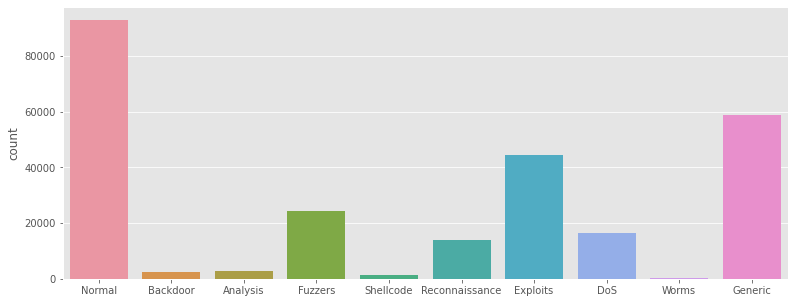

The class ratio for the original data: 0.6:1 (93000/164673)


/usr/local/lib/python3.7/dist-packages/seaborn/_decorators.py:43: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  FutureWarning


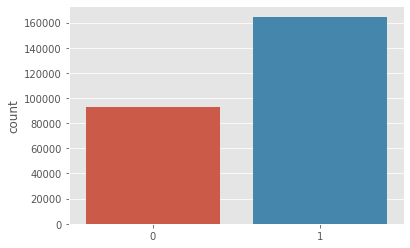

In [10]:
print('The class ratio for the original data:', data_ratio(attacks_type))
plt.figure(figsize=(13,5))
sns.countplot(attacks_type,label="Sum")
plt.show()

print('The class ratio for the original data:', data_ratio(class_type))
sns.countplot(class_type,label="Sum")
plt.show()

In [11]:
combined_data.head(2)

,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087490,252,254,14158.942380,8495.365234,0,0,24.2956,8.375000,30.177547,11.830604,255,621772692,2202533631,255,0.0,0.0,0.0,43,43,0,0,1,0,1,1,1,1,0,0,0,1,1,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,62,252,8395.112305,503571.312500,2,17,49.9150,15.432865,61.426934,1387.778330,255,1417884146,3077387971,255,0.0,0.0,0.0,52,1106,0,0,43,1,1,1,1,2,0,0,0,1,6,0,Normal,0


#Protocol Analyzer

In [12]:
#Separate data according to protocol
udp_data = combined_data.where(combined_data['proto'] == "udp").dropna()
tcp_data = combined_data.where(combined_data['proto'] == "tcp").dropna()
other_prot_data =  combined_data.where(combined_data['proto'] != "tcp").dropna()
other_prot_data =  other_prot_data.where(other_prot_data['proto'] != "udp").dropna()


In [ ]:
tcp_data.shape

#Encoding non numeric Values

In [13]:
#define function to encode categorical values from data
def encode_data(data):
    le1 = LabelEncoder()
    le = LabelEncoder()
    vector = data['attack_cat']

    print("attack cat:", set(list(vector))) # use print to make it print on single line 

    data['attack_cat'] = le1.fit_transform(vector)
    data['proto'] = le.fit_transform(data['proto'])
    data['service'] = le.fit_transform(data['service'])
    data['state'] = le.fit_transform(data['state'])
    return data


In [14]:
udp_data = encode_data( udp_data)
tcp_data = encode_data( tcp_data)
other_prot_data = encode_data( other_prot_data)

attack cat: {'Worms', 'Exploits', 'Shellcode', 'Reconnaissance', 'DoS', 'Normal', 'Backdoor', 'Fuzzers', 'Generic'}
attack cat: {'Worms', 'Exploits', 'Shellcode', 'Reconnaissance', 'DoS', 'Generic', 'Normal', 'Backdoor', 'Fuzzers', 'Analysis'}
attack cat: {'Exploits', 'Reconnaissance', 'DoS', 'Generic', 'Normal', 'Backdoor', 'Fuzzers', 'Analysis'}


#Normalizing Dataset

In [16]:
def normalize_data(data):
    scaler = preprocessing.MinMaxScaler()
    names = data.columns
    d = scaler.fit_transform(data)
    scaled_df = pd.DataFrame(d, columns=names)
    return scaled_df

In [17]:
udp_data = normalize_data( udp_data)
tcp_data = normalize_data( tcp_data)
other_prot_data = normalize_data( other_prot_data)

<h1>Splitting the dataset</h1>

In [34]:
# droped label
udp_data_x = udp_data.drop(['attack_cat','label'], axis=1) 
udp_data_y = udp_data.loc[:,['label']]

tcp_data_x = tcp_data.drop(['attack_cat','label'], axis=1) 
tcp_data_y = tcp_data.loc[:,['label']]

other_data_x = other_prot_data.drop(['attack_cat','label'], axis=1) 
other_data_y = other_prot_data.loc[:,['label']]

udp_X_train, udp_X_test, udp_y_train, udp_y_test = train_test_split(udp_data_x, udp_data_y, test_size=.20, random_state=42) 
tcp_X_train, tcp_X_test, tcp_y_train, tcp_y_test = train_test_split(tcp_data_x, tcp_data_y, test_size=.20, random_state=42) 
udp_X_train, udp_X_test, udp_y_train, udp_y_test = train_test_split(other_data_x, other_data_y, test_size=.20, random_state=42) 

#Features selection

In [ ]:
#Feature selection

chi2_selector = SelectKBest(chi2, k=14)
X_train_kbest = chi2_selector.fit_transform(X_train, y_train)
X_test_kbest = chi2_selector.fit_transform(X_test, y_test)

#print(X_kbest.shape)
# X_train_transform = X_train_kbest
# X_test_transform = X_test_kbest
X_train = X_train_kbest
X_test = X_test_kbest

In [37]:
def feat_select_RFE(data_x,data_y):
  estimator = SVR(kernel="linear")
  selector = RFE(estimator, n_features_to_select=14, step=1)
  data_transform = selector.fit_transform(data_x, data_y) 
  return data_transform

/usr/local/lib/python3.7/dist-packages/sklearn/utils/validation.py:760: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
type(udp_y_train)

In [40]:
# ===== Step 1: cross-validation ========
# define a Logistic Regression classifier
#clf = LogisticRegression(solver='lbfgs', random_state=123, max_iter = 4000)

clf = svm.SVC(kernel='linear') # Linear Kernel

# define  Stratified 5-fold cross-validator, it provides train/validate indices to split data in train/validate sets.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

# define metrics for evaluating
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

# perform the 5-fold CV and get the metrics results
cv_results = cross_validate(estimator=clf,
                            X = feat_select_RFE(udp_X_train,udp_y_train['label'].values),
                            y = udp_y_train['label'].values, 
                            scoring = scoring,
                            cv = cv,
                            return_train_score = False)

In [42]:
clf.fit(udp_X_train_transform, udp_y_train['label'].values)

SVC(C=1.0, break_ties=False, cache_size=200, class_weight=None, coef0=0.0,
    decision_function_shape='ovr', degree=3, gamma='scale', kernel='linear',
    max_iter=-1, probability=False, random_state=None, shrinking=True,
    tol=0.001, verbose=False)

In [43]:
y_pred = clf.predict(feat_select_RFE(udp_X_test,udp_y_test['label'].values))


In [44]:
print("Accuracy:",metrics.accuracy_score(udp_y_test['label'].values, y_pred))

Accuracy: 0.10182425181829022


In [41]:
for key, value in cv_results.items(): 
  print( key,value.mean())

fit_time 0.15829858779907227
score_time 0.04315109252929687
test_accuracy 0.9983305651332287
test_precision 0.9981593320810201
test_recall 1.0
test_f1 0.9990787416222744
test_roc_auc 0.9902650457765189


In [25]:
#Explore different protocols
import collections
from tabulate import tabulate
counter = collections.Counter(combined_data['proto'])  
print(tabulate(counter.most_common(),headers = ['Type','Occurences']))

Type           Occurences
-----------  ------------
tcp                123041
udp                 92701
unas                15599
arp                  3846
ospf                 3271
sctp                 1474
any                   396
gre                   313
rsvp                  264
ipv6                  262
sun-nd                255
swipe                 253
mobile                253
pim                   253
sep                   251
prm                   133
xns-idp               133
leaf-1                133
ddp                   132
ipv6-frag             132
cftp                  132
wsn                   132
pvp                   132
wb-expak              132
mtp                   132
pri-enc               132
sat-mon               132
cphb                  132
iso-ip                132
xtp                   132
il                    132
mfe-nsp               132
3pc                   132
ipv6-route            132
idrp                  132
bna                   132
kryptolan   